# LLR Comparison: Base ESM2 vs LoRA-Finetuned (per-pfam)

Loads the LoRA delta weights produced by `ESM_domainome_ft_pfam.ipynb` for each pfam,
recomputes per-domain LLR matrices with both the un-finetuned base model and the
finetuned model for that pfam, and uploads one gzipped pickle per pfam to GCS:
`{domain_id: {sequence, seq_offset, base_llr, ft_llr, delta_llr, ...}}`.

Output paths mirror the training run, i.e. one
`llr_comparison_all.pkl.gz` per pfam under
`gs://{bucket}/{prefix}/global_finetune/{pfam_id}/`.


In [ ]:
!pip install -q -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 65.6 MB/s eta 0:00:00


In [ ]:
import os
import io
import gzip
import json
import pickle
import warnings
import logging

import numpy as np
import pandas as pd
import torch

from dotenv import load_dotenv
from tqdm import tqdm

from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model
from google.cloud import storage

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

In [ ]:
# ── Constants (must match training run) ──────────────────────────────────────

AA_ORDER         = ['L', 'A', 'G', 'V', 'S', 'E', 'R', 'T', 'I', 'D',
                    'P', 'K', 'Q', 'N', 'F', 'Y', 'M', 'H', 'W', 'C']
FITNESS_AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")
MODEL_NAME       = "facebook/esm2_t33_650M_UR50D"
MAX_LEN          = 1022
LORA_DROPOUT     = 0.1

# ── Local + GCS layout (must match training run) ─────────────────────────────

# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "plm-study-484223-e1c13b49d132.json"

OUTPUT_DIR     = "finetuned_models_v2"
RUN_ID_PREFIX  = "global_finetune"   # matches training notebook's run_id = f"{RUN_ID_PREFIX}/{pfam_id}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

GCS_PROJECT           = "plm-study-484223"
GCS_BUCKET            = "domainome-data"
GCS_DOMAIN_DATA_BLOB  = "ESM2/dict_fitness.pkl.gz"
GCS_FULL_PROTEIN_BLOB = "ESM2/dict_domainome_uniprot_new.pkl.gz"
GCS_OUTPUT_PREFIX     = "ESM2/ft_per_pfam/"   # must end with /

LLR_OUTPUT_NAME = "llr_comparison_all.pkl.gz"


def pfam_paths(pfam_id):
    """Resolve all per-pfam local + GCS paths from a pfam id."""
    run_id  = f"{RUN_ID_PREFIX}/{pfam_id}"
    run_dir = os.path.join(OUTPUT_DIR, run_id)
    # os.makedirs(run_dir, exist_ok=True)
    return {
        "run_id":        run_id,
        "run_dir":       run_dir,
        "metadata_local": os.path.join(run_dir, "metadata.json"),
        "lora_local":    os.path.join(run_dir, "best_model_lora.pth"),
        "llr_local":     os.path.join(run_dir, LLR_OUTPUT_NAME),
        "gcs_metadata":  f"{GCS_OUTPUT_PREFIX}{run_id}/metadata.json",
        "gcs_lora":      f"{GCS_OUTPUT_PREFIX}{run_id}/best_model_lora.pth",
        "gcs_llr":       f"{GCS_OUTPUT_PREFIX}{run_id}/{LLR_OUTPUT_NAME}",
    }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
# ── GCS Helpers ──────────────────────────────────────────────────────────────
# load_dotenv()
# cred_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')

# os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = cred_path

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] ='plm-study-484223-e1c13b49d132.json'

# _gcs_client = storage.Client(project=GCS_PROJECT) if GCS_PROJECT else storage.Client()
_gcs_client = storage.Client()
_gcs_bucket = _gcs_client.bucket(GCS_BUCKET)


def gcs_download_pickle_gz(blob):
    data = blob.download_as_bytes()
    with gzip.GzipFile(fileobj=io.BytesIO(data), mode="rb") as gz:
        return pickle.load(gz)


def gcs_download_to_file(blob_path, local_path):
    blob = _gcs_bucket.blob(blob_path)
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    blob.download_to_filename(local_path)
    return local_path


def gcs_upload_file(blob_path, local_path, content_type="application/octet-stream"):
    blob = _gcs_bucket.blob(blob_path)
    blob.upload_from_filename(local_path, content_type=content_type)

In [ ]:
# ── Helpers (mirrored from training notebook) ────────────────────────────────

def truncate_to_domain(sequence, domain_start, domain_end, max_len=MAX_LEN):
    seq_len    = len(sequence)
    domain_mid = (domain_start + domain_end) // 2
    half       = max_len // 2
    start      = max(0, domain_mid - 1 - half)
    end        = start + max_len
    if end > seq_len:
        end   = seq_len
        start = max(0, end - max_len)
    return sequence[start:end], start


def get_LLR_scores(sequence, model, tokenizer, device):
    seq_list  = list(sequence)
    tokenized = tokenizer(sequence, padding=False, truncation=True,
                          max_length=1024, return_tensors="pt")
    input_ids = tokenized["input_ids"].to(device)

    logits    = model(input_ids).logits
    log_probs = torch.log_softmax(logits, dim=-1)
    wt_logits = log_probs[:, 1:-1, :].squeeze(0)

    wt_logits_df = pd.DataFrame(
        wt_logits[:, 4:24].cpu().detach().numpy(),
        columns=AA_ORDER,
        index=[f"{aa} {i+1}" for i, aa in enumerate(seq_list)]
    ).T

    wt_norm = np.diag(wt_logits_df.loc[[c.split(" ")[0] for c in wt_logits_df.columns]])
    LLR     = wt_logits_df - wt_norm
    return LLR, wt_logits, seq_list


def fitness_matrix_to_rows(fitness, dom_seq, position_offset=0):
    rows = []
    for i, wt_aa in enumerate(dom_seq):
        if i >= len(fitness):
            break
        row = fitness[i]
        for j, mut_aa in enumerate(FITNESS_AA_ORDER):
            if j >= len(row):
                continue
            val = row[j]
            if val is None:
                continue
            try:
                fval = float(val)
            except (TypeError, ValueError):
                continue
            if np.isnan(fval):
                continue
            if mut_aa == wt_aa:
                continue
            rows.append({
                "position":           position_offset + i + 1,
                "wt_aa":              wt_aa,
                "mut_aa":             mut_aa,
                "normalized_fitness": fval,
            })
    return rows


def build_lora_model(lora_r, lora_alpha):
    """Rebuild the exact ESM2 + LoRA architecture used during training."""
    model       = EsmForMaskedLM.from_pretrained(MODEL_NAME)
    lora_config = LoraConfig(
        task_type      = "FEATURE_EXTRACTION",
        r              = lora_r,
        lora_alpha     = lora_alpha,
        target_modules = ["query", "key", "value", "output.dense"],
        lora_dropout   = LORA_DROPOUT,
    )
    model = get_peft_model(model, lora_config)
    return model


def recover_domains_from_metadata(metadata):
    """Pull per-domain {sequence, seq_offset, ...} out of a pfam's metadata.json.

    The training notebook writes a `domains` block per pfam that already
    contains the truncated input sequence and seq_offset used at training time,
    so we just normalize the fields here.
    """
    out = {}
    meta_domains = metadata.get("domains") or {}
    for domain_id, dinfo in meta_domains.items():
        if not isinstance(dinfo, dict) or "sequence" not in dinfo:
            continue
        out[domain_id] = {
            "uniprot_id":           dinfo.get("uniprot_id"),
            "sequence":             dinfo["sequence"],
            "seq_offset":           int(dinfo.get("seq_offset", 0)),
            "used_full_protein":    bool(dinfo.get("used_full_protein", False)),
            "dom_start_in_protein": int(dinfo.get("dom_start_in_protein", 0)),
        }
    return out

def gcs_download_bytes(gcs_path, bucket_name=GCS_BUCKET):
    """
    Download a GCS object directly into memory as bytes.
    """
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(gcs_path)

    return blob.download_as_bytes()


def gcs_upload_bytes(
    gcs_path,
    data_bytes,
    bucket_name=GCS_BUCKET,
    content_type=None
):
    """
    Upload raw bytes directly to GCS from memory.
    """
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(gcs_path)

    blob.upload_from_file(
        io.BytesIO(data_bytes),
        size=len(data_bytes),
        content_type=content_type
    )

In [ ]:
# ── Discover pfams from GCS ──────────────────────────────────────────────────
#
# The training notebook writes one directory per pfam under
# `GCS_OUTPUT_PREFIX{RUN_ID_PREFIX}/{pfam_id}/` (each containing a
# `metadata.json` + `best_model_lora.pth`). We list those blobs and recover
# the set of pfam ids that have a finetuned model available.

_run_prefix = f"{GCS_OUTPUT_PREFIX}{RUN_ID_PREFIX}/"

PFAM_IDS = sorted({
    blob.name[len(_run_prefix):].split("/", 1)[0]
    for blob in _gcs_client.list_blobs(GCS_BUCKET, prefix=_run_prefix)
    if blob.name.endswith("/metadata.json")
})

print(f"Found {len(PFAM_IDS)} pfams under gs://{GCS_BUCKET}/{_run_prefix}")
print(PFAM_IDS[:10], "..." if len(PFAM_IDS) > 10 else "")


Found 126 pfams under gs://domainome-data/ESM2/ft_per_pfam/global_finetune/
['PF00010', 'PF00013', 'PF00018', 'PF00030', 'PF00035', 'PF00046', 'PF00096', 'PF00105', 'PF00130', 'PF00157'] ...


In [ ]:
# ── Load tokenizer + base ESM2 (once, shared across pfams) ───────────────────

tokenizer = EsmTokenizer.from_pretrained(MODEL_NAME)

print("Loading base ESM2...")
base_model = EsmForMaskedLM.from_pretrained(MODEL_NAME).to(device)
base_model.eval()


Loading base ESM2...


Loading weights:   0%|          | 0/571 [00:00<?, ?it/s]

EsmForMaskedLM(
  (esm): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(33, 1280, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-32): 33 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=1280, out_features=1280, bias=True)
              (key): Linear(in_features=1280, out_features=1280, bias=True)
              (value): Linear(in_features=1280, out_features=1280, bias=True)
              (rotary_embeddings): RotaryEmbedding()
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=1280, out_features=1280, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
          )
          (intermediate): EsmIntermediate(
            (dense): Linear(in_features=1

In [ ]:
# ── Per-pfam loop: run each FT model over EVERY domain in the dataset ────────
#
# For each pfam we load its LoRA-finetuned model and compute base + ft LLRs
# over every domain in `fitness_dict`, not just the domains that belong to
# that pfam's training metadata. Per-domain input sequences (and the base
# LLR, which is pfam-independent) are computed once and reused across pfams.

device = torch.device("cpu")

base_model.to(device)
base_model.eval()

# 1. Load fitness_dict + full_protein_dict once (shared across pfams)
print(f"Loading fitness dict from gs://{GCS_BUCKET}/{GCS_DOMAIN_DATA_BLOB}")
fitness_dict = gcs_download_pickle_gz(_gcs_bucket.blob(GCS_DOMAIN_DATA_BLOB))
print(f"  → {len(fitness_dict)} domain entries")

print(f"Loading full protein dict from gs://{GCS_BUCKET}/{GCS_FULL_PROTEIN_BLOB}")
full_protein_dict = gcs_download_pickle_gz(_gcs_bucket.blob(GCS_FULL_PROTEIN_BLOB))
print(f"  → {len(full_protein_dict)} full protein entries")

# 2. Build per-domain model input (sequence, seq_offset) once.
#    Mirrors the truncation logic from ESM_domainome_ft_pfam.ipynb so that
#    LLR positions line up with the training-time inputs.
domain_inputs = {}
for domain_id, d in tqdm(fitness_dict.items(), desc="Preparing domain inputs"):
    if not isinstance(d, dict):
        continue
    dom_seq    = d.get("dom_seq")
    uniprot_id = d.get("uniprot_id")
    if not dom_seq:
        continue

    full_seq             = None
    dom_start_in_protein = 0
    entry = full_protein_dict.get(uniprot_id)
    if entry:
        candidate = entry.get("sequence") if isinstance(entry, dict) else entry
        if candidate:
            idx = candidate.find(dom_seq)
            if idx >= 0:
                full_seq             = candidate
                dom_start_in_protein = idx

    if full_seq is not None:
        sequence   = full_seq
        seq_offset = 0
        if len(sequence) > MAX_LEN:
            dom_start_1idx = dom_start_in_protein + 1
            dom_end_1idx   = dom_start_in_protein + len(dom_seq)
            sequence, seq_offset = truncate_to_domain(
                sequence, dom_start_1idx, dom_end_1idx
            )
    else:
        sequence   = dom_seq
        seq_offset = 0
        if len(sequence) > MAX_LEN:
            sequence, seq_offset = truncate_to_domain(
                sequence, 1, len(dom_seq)
            )

    domain_inputs[domain_id] = {
        "uniprot_id":           uniprot_id,
        "sequence":             sequence,
        "seq_offset":           seq_offset,
        "used_full_protein":    full_seq is not None,
        "dom_start_in_protein": dom_start_in_protein,
    }

print(f"Prepared inputs for {len(domain_inputs)} domains")

# 3. Compute base LLR once per domain (pfam-independent — reuse across pfams)
print("Computing base LLRs for all domains (once)...")
base_llrs = {}
with torch.no_grad():
    for domain_id, dinfo in tqdm(domain_inputs.items(), desc="Base LLRs"):
        base_LLR, _, _ = get_LLR_scores(
            dinfo["sequence"], base_model, tokenizer, device
        )
        base_llrs[domain_id] = {
            "positions": list(base_LLR.columns),
            "matrix":    base_LLR.to_numpy().astype(np.float32),
        }

# 4. For each pfam, load its FT model and compute ft_llr over every domain
pfam_payloads = {}

for pfam_id in tqdm(PFAM_IDS, desc="Pfams"):

    paths = pfam_paths(pfam_id)

    metadata_bytes = gcs_download_bytes(paths["gcs_metadata"])
    metadata = json.loads(metadata_bytes.decode("utf-8"))

    best_cfg = metadata["best_config"]

    lora_bytes = gcs_download_bytes(paths["gcs_lora"])

    ft_model = build_lora_model(
        best_cfg["lora_r"],
        best_cfg["lora_alpha"]
    )

    lora_buffer = io.BytesIO(lora_bytes)

    lora_state = torch.load(
        lora_buffer,
        map_location="cpu"
    )

    ft_model.load_state_dict(lora_state, strict=False)
    ft_model.to(device)
    ft_model.eval()

    pfam_train_domains = set(recover_domains_from_metadata(metadata).keys())

    llr_dict = {}

    with torch.no_grad():

        for domain_id, dinfo in tqdm(
            domain_inputs.items(),
            desc=f"{pfam_id} domains",
            leave=False,
        ):

            sequence = dinfo["sequence"]

            ft_LLR, _, _ = get_LLR_scores(
                sequence,
                ft_model,
                tokenizer,
                device
            )

            base_mat = base_llrs[domain_id]["matrix"]
            ft_mat   = ft_LLR.to_numpy().astype(np.float32)
            delta    = ft_mat - base_mat

            llr_dict[domain_id] = {
                "uniprot_id":           dinfo["uniprot_id"],
                "sequence":             sequence,
                "seq_offset":           dinfo["seq_offset"],
                "used_full_protein":    dinfo["used_full_protein"],
                "dom_start_in_protein": dinfo["dom_start_in_protein"],
                "aa_order":             AA_ORDER,
                "positions":            base_llrs[domain_id]["positions"],
                "base_llr":             base_mat,
                "ft_llr":               ft_mat,
                "delta_llr":            delta,
                "in_pfam_train":        domain_id in pfam_train_domains,
            }

    payload = {
        "run_id":      paths["run_id"],
        "pfam_id":     pfam_id,
        "model_name":  MODEL_NAME,
        "best_config": best_cfg,
        "aa_order":    AA_ORDER,
        "n_domains":   len(llr_dict),
        "n_train_domains": len(pfam_train_domains),
        "domains":     llr_dict,
    }

    pfam_payloads[pfam_id] = payload

    payload_buffer = io.BytesIO()

    with gzip.GzipFile(
        fileobj=payload_buffer,
        mode="wb",
        compresslevel=6
    ) as gz:
        pickle.dump(
            payload,
            gz,
            protocol=pickle.HIGHEST_PROTOCOL
        )

    payload_bytes = payload_buffer.getvalue()
    size_mb = len(payload_bytes) / 1e6

    gcs_upload_bytes(
        paths["gcs_llr"],
        payload_bytes,
        content_type="application/gzip"
    )

    tqdm.write(
        f"[{pfam_id}] {len(llr_dict)} domains "
        f"({len(pfam_train_domains)} in train), "
        f"{size_mb:.1f} MB → "
        f"gs://{GCS_BUCKET}/{paths['gcs_llr']}"
    )

    del ft_model

print(f"\nDone — wrote payloads for {len(pfam_payloads)} pfams")

Loading fitness dict from gs://domainome-data/ESM2/dict_fitness.pkl.gz
  → 522 domain entries
Loading full protein dict from gs://domainome-data/ESM2/dict_domainome_uniprot_new.pkl.gz
  → 428 full protein entries


Preparing domain inputs: 100%|██████████| 522/522 [00:00<00:00, 144468.93it/s]


Prepared inputs for 522 domains
Computing base LLRs for all domains (once)...


Pfams:   0%|          | 0/126 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/571 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/571 [00:00<?, ?it/s]


Pfams:  55%|█████▍    | 69/126 [23:01:09<19:30:30, 1232.12s/it]

[PF02295] 522 domains (2 in train), 73.6 MB → gs://domainome-data/ESM2/ft_per_pfam/global_finetune/PF02295/llr_comparison_all.pkl.gz


Loading weights:   0%|          | 0/571 [00:00<?, ?it/s]


PF02359 domains:  81%|████████  | 421/522 [16:41<05:05,  3.03s/it]

In [ ]:
# # ── Per-pfam loop: load LoRA, compute base/ft/Δ LLRs, save payload (CPU) ─────

# # Force CPU execution
# device = torch.device("cpu")

# # Move base model to CPU once
# base_model.to(device)
# base_model.eval()

# pfam_payloads = {}

# for pfam_id in tqdm(PFAM_IDS, desc="Pfams"):
#     paths = pfam_paths(pfam_id)

#     # 1. Download metadata + LoRA weights if needed
#     if not os.path.exists(paths["metadata_local"]):
#         gcs_download_to_file(paths["gcs_metadata"], paths["metadata_local"])

#     if not os.path.exists(paths["lora_local"]):
#         gcs_download_to_file(paths["gcs_lora"], paths["lora_local"])

#     with open(paths["metadata_local"]) as f:
#         metadata = json.load(f)

#     best_cfg = metadata["best_config"]

#     # 2. Rebuild LoRA model on CPU
#     ft_model = build_lora_model(
#         best_cfg["lora_r"],
#         best_cfg["lora_alpha"]
#     )

#     lora_state = torch.load(
#         paths["lora_local"],
#         map_location="cpu"
#     )

#     ft_model.load_state_dict(lora_state, strict=False)
#     ft_model.to(device)
#     ft_model.eval()

#     # 3. Recover domains
#     domains = recover_domains_from_metadata(metadata)

#     if not domains:
#         print(f"[{pfam_id}] no domains in metadata — skipping")
#         del ft_model
#         continue

#     # 4. Compute base + finetuned LLRs
#     llr_dict = {}

#     with torch.no_grad():
#         for domain_id, dinfo in domains.items():

#             sequence   = dinfo["sequence"]
#             seq_offset = dinfo["seq_offset"]

#             base_LLR, _, _ = get_LLR_scores(
#                 sequence,
#                 base_model,
#                 tokenizer,
#                 device
#             )

#             ft_LLR, _, _ = get_LLR_scores(
#                 sequence,
#                 ft_model,
#                 tokenizer,
#                 device
#             )

#             delta_LLR = ft_LLR - base_LLR

#             llr_dict[domain_id] = {
#                 "uniprot_id":           dinfo.get("uniprot_id"),
#                 "sequence":             sequence,
#                 "seq_offset":           seq_offset,
#                 "used_full_protein":    dinfo.get("used_full_protein", False),
#                 "dom_start_in_protein": dinfo.get("dom_start_in_protein", 0),
#                 "aa_order":             AA_ORDER,
#                 "positions":            list(base_LLR.columns),
#                 "base_llr":             base_LLR.to_numpy().astype(np.float32),
#                 "ft_llr":               ft_LLR.to_numpy().astype(np.float32),
#                 "delta_llr":            delta_LLR.to_numpy().astype(np.float32),
#             }

#     # 5. Build payload + upload
#     payload = {
#         "run_id":      paths["run_id"],
#         "pfam_id":     pfam_id,
#         "model_name":  MODEL_NAME,
#         "best_config": best_cfg,
#         "aa_order":    AA_ORDER,
#         "n_domains":   len(llr_dict),
#         "domains":     llr_dict,
#     }

#     pfam_payloads[pfam_id] = payload

#     with gzip.open(paths["llr_local"], "wb", compresslevel=6) as gz:
#         pickle.dump(payload, gz, protocol=pickle.HIGHEST_PROTOCOL)

#     size_mb = os.path.getsize(paths["llr_local"]) / 1e6

#     gcs_upload_file(
#         paths["gcs_llr"],
#         paths["llr_local"],
#         content_type="application/gzip"
#     )

#     tqdm.write(
#         f"[{pfam_id}] {len(llr_dict)} domains, "
#         f"{size_mb:.1f} MB → "
#         f"gs://{GCS_BUCKET}/{paths['gcs_llr']}"
#     )

#     del ft_model

# print(f"\nDone — wrote payloads for {len(pfam_payloads)} pfams")

In [ ]:
# # ── Per-pfam loop: load LoRA, compute base/ft/Δ LLRs, save payload ───────────
# #
# # For every pfam discovered above we:
# #   1. Download (or use cached) metadata.json + best_model_lora.pth
# #   2. Rebuild the LoRA architecture and load the finetuned weights
# #   3. Recover that pfam's per-domain {sequence, seq_offset, ...} from metadata
# #   4. Compute base + finetuned LLRs for each of the pfam's domains
# #   5. Pickle a single payload dict for the pfam and upload to GCS
# #
# # All per-pfam payloads are also kept in `pfam_payloads` for downstream cells.

# pfam_payloads = {}

# for pfam_id in tqdm(PFAM_IDS, desc="Pfams"):
#     paths = pfam_paths(pfam_id)

#     # 1. Metadata + LoRA weights
#     if not os.path.exists(paths["metadata_local"]):
#         gcs_download_to_file(paths["gcs_metadata"], paths["metadata_local"])
#     if not os.path.exists(paths["lora_local"]):
#         gcs_download_to_file(paths["gcs_lora"], paths["lora_local"])

#     with open(paths["metadata_local"]) as f:
#         metadata = json.load(f)

#     best_cfg = metadata["best_config"]

#     # 2. Rebuild LoRA + load finetuned weights for this pfam
#     ft_model = build_lora_model(best_cfg["lora_r"], best_cfg["lora_alpha"])
#     lora_state = torch.load(paths["lora_local"], map_location="cpu")
#     ft_model.load_state_dict(lora_state, strict=False)
#     ft_model.to(device)
#     ft_model.eval()

#     # 3. Recover this pfam's domains
#     domains = recover_domains_from_metadata(metadata)
#     if not domains:
#         print(f"[{pfam_id}] no domains in metadata — skipping")
#         del ft_model
#         torch.cuda.empty_cache()
#         continue

#     # 4. Compute LLRs with both models
#     llr_dict = {}
#     with torch.no_grad():
#         for domain_id, dinfo in domains.items():
#             sequence   = dinfo["sequence"]
#             seq_offset = dinfo["seq_offset"]

#             base_LLR, _, _ = get_LLR_scores(sequence, base_model, tokenizer, device)
#             ft_LLR,   _, _ = get_LLR_scores(sequence, ft_model,   tokenizer, device)
#             delta_LLR      = ft_LLR - base_LLR

#             llr_dict[domain_id] = {
#                 "uniprot_id":           dinfo.get("uniprot_id"),
#                 "sequence":             sequence,
#                 "seq_offset":           seq_offset,
#                 "used_full_protein":    dinfo.get("used_full_protein", False),
#                 "dom_start_in_protein": dinfo.get("dom_start_in_protein", 0),
#                 "aa_order":             AA_ORDER,
#                 "positions":            list(base_LLR.columns),
#                 "base_llr":             base_LLR.to_numpy().astype(np.float32),
#                 "ft_llr":               ft_LLR.to_numpy().astype(np.float32),
#                 "delta_llr":            delta_LLR.to_numpy().astype(np.float32),
#             }

#     # 5. Build the payload dict for this pfam, pickle locally + upload to GCS
#     payload = {
#         "run_id":      paths["run_id"],
#         "pfam_id":     pfam_id,
#         "model_name":  MODEL_NAME,
#         "best_config": best_cfg,
#         "aa_order":    AA_ORDER,
#         "n_domains":   len(llr_dict),
#         "domains":     llr_dict,
#     }
#     pfam_payloads[pfam_id] = payload

#     with gzip.open(paths["llr_local"], "wb", compresslevel=6) as gz:
#         pickle.dump(payload, gz, protocol=pickle.HIGHEST_PROTOCOL)

#     size_mb = os.path.getsize(paths["llr_local"]) / 1e6
#     gcs_upload_file(paths["gcs_llr"], paths["llr_local"], content_type="application/gzip")

#     tqdm.write(
#         f"[{pfam_id}] {len(llr_dict)} domains, {size_mb:.1f} MB → "
#         f"gs://{GCS_BUCKET}/{paths['gcs_llr']}"
#     )

#     del ft_model
#     torch.cuda.empty_cache()

# print(f"\nDone — wrote payloads for {len(pfam_payloads)} pfams")


In [ ]:
# ── Quick sanity summary across all pfams ────────────────────────────────────

summary_rows = []
for pfam_id, payload in pfam_payloads.items():
    delta_means     = []
    delta_abs_means = []
    max_abs = 0.0
    for v in payload["domains"].values():
        delta_means.append(float(np.nanmean(v["delta_llr"])))
        delta_abs_means.append(float(np.nanmean(np.abs(v["delta_llr"]))))
        max_abs = max(max_abs, float(np.nanmax(np.abs(v["delta_llr"]))))
    summary_rows.append({
        "pfam_id":       pfam_id,
        "n_domains":     payload["n_domains"],
        "mean_delta":    float(np.mean(delta_means))     if delta_means     else float("nan"),
        "mean_abs_delta": float(np.mean(delta_abs_means)) if delta_abs_means else float("nan"),
        "max_abs_delta": max_abs,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("mean_abs_delta", ascending=False)
print(summary_df.head(20).to_string(index=False))
print(f"\nOverall mean ΔLLR:    {summary_df['mean_delta'].mean():+.4f}")
print(f"Overall mean |ΔLLR|:  {summary_df['mean_abs_delta'].mean():.4f}")


pfam_id  n_domains  mean_delta  mean_abs_delta  max_abs_delta
PF01246          1   11.824181       11.825676      22.642061
PF18044          1    8.807133        8.815209      19.887589
PF09329          1    6.665559        6.678056      18.238441
PF02270          1    5.584611        5.641061      14.467826
PF00240          1    5.471704        5.521106      13.816420
PF00536          6    5.198285        5.292124      23.137259
PF10650          1    5.090836        5.281365      19.663757
PF02008          1    4.445914        4.485033      16.549803
PF03638          1    4.430459        4.434912      17.418621
PF07525          2    4.287336        4.420163      14.479683
PF02185          1    4.083700        4.179096      15.881168
PF00831          1    4.061095        4.125867      12.992704
PF12678          1    3.926712        4.000082      11.341683
PF00030         12    3.760845        3.894638      16.572943
PF02209          4    3.600417        3.683440      15.969111
PF11793 

## Reload a pfam's comparison dict

```python
import gzip, io, pickle, pandas as pd
from google.cloud import storage

pfam_id = "PF00001"  # pick one

blob = storage.Client().bucket("<bucket>").blob(
    f"<prefix>/global_finetune/{pfam_id}/llr_comparison_all.pkl.gz"
)
with gzip.open(io.BytesIO(blob.download_as_bytes()), "rb") as gz:
    payload = pickle.load(gz)

entry    = payload["domains"]["<domain_id>"]
base_df  = pd.DataFrame(entry["base_llr"],  index=entry["aa_order"], columns=entry["positions"])
ft_df    = pd.DataFrame(entry["ft_llr"],    index=entry["aa_order"], columns=entry["positions"])
delta_df = pd.DataFrame(entry["delta_llr"], index=entry["aa_order"], columns=entry["positions"])
```


In [ ]:
# ── Reload per-pfam payloads (skip recompute) ────────────────────────────────
#
# For each pfam under PFAM_IDS, prefer the local pickle and fall back to
# downloading from GCS. Populates `pfam_payloads` so the Spearman + plotting
# cells below run without recomputing LLRs.

pfam_payloads = {}

for pfam_id in PFAM_IDS:
    paths = pfam_paths(pfam_id)
    if not os.path.exists(paths["llr_local"]):
        try:
            gcs_download_to_file(paths["gcs_llr"], paths["llr_local"])
        except Exception as exc:
            print(f"[{pfam_id}] download failed: {exc}")
            continue
    with gzip.open(paths["llr_local"], "rb") as gz:
        pfam_payloads[pfam_id] = pickle.load(gz)

print(f"Loaded payloads for {len(pfam_payloads)} pfams")
if pfam_payloads:
    sample_pfam = next(iter(pfam_payloads))
    sample_payload = pfam_payloads[sample_pfam]
    sample_id   = next(iter(sample_payload["domains"]))
    sample      = sample_payload["domains"][sample_id]
    print(f"Sample pfam={sample_pfam} domain={sample_id} "
          f"seq_len={len(sample['sequence'])} "
          f"base_llr={sample['base_llr'].shape} "
          f"ft_llr={sample['ft_llr'].shape}")


Loaded payloads for 126 pfams
Sample pfam=PF00010 domain=P50539_PF00010_70 seq_len=228 base_llr=(20, 228) ft_llr=(20, 228)


In [ ]:
# ── Spearman: fitness vs (base LLR, finetuned LLR) per domain × pfam ────────
#
# For every domain across every pfam in `pfam_payloads`, line up each measured
# (position, mut_aa) fitness value with the corresponding entry in the base and
# finetuned LLR matrices and compute Spearman ρ separately for base and ft.

from scipy.stats import spearmanr

try:
    fitness_dict
except NameError:
    print(f"Loading fitness dict from gs://{GCS_BUCKET}/{GCS_DOMAIN_DATA_BLOB}")
    fitness_dict = gcs_download_pickle_gz(_gcs_bucket.blob(GCS_DOMAIN_DATA_BLOB))
    print(f"Loaded {len(fitness_dict)} fitness entries")

aa_to_row = {aa: i for i, aa in enumerate(AA_ORDER)}

per_domain_rows = []
skipped_no_match = 0
skipped_too_few  = 0

for pfam_id, payload in tqdm(pfam_payloads.items(), desc="Pfams"):
    for domain_id, entry in payload["domains"].items():
        fd = fitness_dict.get(domain_id)
        if not isinstance(fd, dict):
            continue
        fitness = fd.get("fitness")
        dom_seq = fd.get("dom_seq")
        if fitness is None or dom_seq is None:
            continue

        sequence = entry["sequence"]
        base_llr = entry["base_llr"]
        ft_llr   = entry["ft_llr"]
        n_pos    = base_llr.shape[1]

        idx_in_seq = sequence.find(dom_seq)
        if idx_in_seq < 0:
            skipped_no_match += 1
            continue

        fits, base_vals, ft_vals = [], [], []
        for i, wt_aa in enumerate(dom_seq):
            col = idx_in_seq + i
            if col >= n_pos or i >= len(fitness):
                break
            row = fitness[i]
            for j, mut_aa in enumerate(FITNESS_AA_ORDER):
                if j >= len(row):
                    continue
                val = row[j]
                if val is None or mut_aa == wt_aa:
                    continue
                try:
                    fval = float(val)
                except (TypeError, ValueError):
                    continue
                if np.isnan(fval):
                    continue
                r = aa_to_row.get(mut_aa)
                if r is None:
                    continue
                fits.append(fval)
                base_vals.append(float(base_llr[r, col]))
                ft_vals.append(float(ft_llr[r, col]))

        if len(fits) < 10:
            skipped_too_few += 1
            continue

        fits      = np.asarray(fits)
        base_vals = np.asarray(base_vals)
        ft_vals   = np.asarray(ft_vals)

        rho_base, p_base = spearmanr(fits, base_vals)
        rho_ft,   p_ft   = spearmanr(fits, ft_vals)

        per_domain_rows.append({
            "pfam_id":    pfam_id,
            "domain_id":  domain_id,
            "uniprot_id": entry.get("uniprot_id"),
            "n":          int(len(fits)),
            "rho_base":   float(rho_base),
            "p_base":     float(p_base),
            "rho_ft":     float(rho_ft),
            "p_ft":       float(p_ft),
            "delta_rho":  float(rho_ft - rho_base),
        })

corr_df = pd.DataFrame(per_domain_rows).sort_values("delta_rho", ascending=False)

print(f"Computed Spearman for {len(corr_df)} domains "
      f"(skipped {skipped_no_match} no-match, {skipped_too_few} too-few)")
print(f"Mean ρ_base : {corr_df['rho_base'].mean():+.4f}   "
      f"median {corr_df['rho_base'].median():+.4f}")
print(f"Mean ρ_ft   : {corr_df['rho_ft'].mean():+.4f}   "
      f"median {corr_df['rho_ft'].median():+.4f}")
print(f"Mean Δρ     : {corr_df['delta_rho'].mean():+.4f}   "
      f"median {corr_df['delta_rho'].median():+.4f}")
print(f"Domains improved (Δρ > 0): "
      f"{(corr_df['delta_rho'] > 0).sum()} / {len(corr_df)} "
      f"({(corr_df['delta_rho'] > 0).mean()*100:.1f}%)")

corr_df.head(10)


Loading fitness dict from gs://domainome-data/ESM2/dict_fitness.pkl.gz
Loaded 522 fitness entries


Pfams: 100%|██████████| 126/126 [00:00<00:00, 161.86it/s]

Computed Spearman for 519 domains (skipped 0 no-match, 0 too-few)
Mean ρ_base : +0.4498   median +0.4492
Mean ρ_ft   : +0.4945   median +0.5151
Mean Δρ     : +0.0448   median +0.0271
Domains improved (Δρ > 0): 352 / 519 (67.8%)


,pfam_id,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho
479,PF11722,Q9NUP7_PF11722_18,Q9NUP7,439,0.026799,5.754848e-01,0.539265,1.734913e-34,0.512467
266,PF00569,Q9Y4J8_PF00569_235,Q9Y4J8,1119,0.188505,2.073700e-10,0.629436,1.625794e-124,0.440931
415,PF02209,P09327_PF02209_793,P09327,632,0.186976,2.212267e-06,0.618647,5.136239e-68,0.431671
401,PF02187,Q99501_PF02187_209,Q99501,1241,0.317365,1.942498e-30,0.745177,2.934920e-220,0.427811
360,PF01246,Q9UHA3_PF01246_2,Q9UHA3,1068,0.076644,1.222822e-02,0.482567,2.178054e-63,0.405923
454,PF06467,Q9UJ78_PF06467_334,Q9UJ78,678,0.186344,1.029017e-06,0.587158,4.585924e-64,0.400814
512,PF18044,Q8WU90_PF18044_104,Q8WU90,397,0.166906,8.422100e-04,0.541368,1.312076e-31,0.374462
366,PF01429,P51608_PF01429_91,P51608,1364,0.239725,2.790214e-19,0.604755,7.981599e-137,0.365030
419,PF02295,P55265_PF02295_296,P55265,1147,0.248485,1.334603e-17,0.606643,3.112483e-116,0.358158
355,PF00787,Q96L93_PF00787_1213,Q96L93,1064,0.052066,8.960303e-02,0.404869,3.114693e-43,0.352803


In [ ]:
corr_df.sort_values("pfam_id").head(30)

,pfam_id,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho
0,PF00010,P50539_PF00010_70,P50539,939,0.271619,2.413463e-17,0.493691,7.603561e-59,0.222072
1,PF00010,Q05195_PF00010_58,Q05195,938,0.201825,4.452025e-10,0.510663,1.966802e-63,0.308838
3,PF00013,Q06787_PF00013_217,Q06787,1212,0.429986,1.027802e-55,0.460133,1.538933e-64,0.030147
2,PF00013,P61978_PF00013_385,P61978,1406,0.359444,3.920498e-44,0.415475,8.654241e-60,0.056032
10,PF00013,Q96I24_PF00013_75,Q96I24,1443,0.451784,1.704134e-73,0.655272,8.967053e-178,0.203488
4,PF00013,Q15365_PF00013_278,Q15365,1360,0.370118,2.092788e-45,0.695142,6.704938e-197,0.325024
9,PF00013,Q96AE4_PF00013_98,Q96AE4,1341,0.399393,1.614882e-52,0.594967,3.313053e-129,0.195574
8,PF00013,Q96AE4_PF00013_184,Q96AE4,1406,0.483132,4.016785e-83,0.642705,1.168421e-164,0.159573
7,PF00013,Q92945_PF00013_142,Q92945,1387,0.412251,4.940292e-58,0.653580,8.915567e-170,0.241328
6,PF00013,Q86XN8_PF00013_273,Q86XN8,1260,0.605706,5.057738e-127,0.612489,1.289988e-130,0.006783


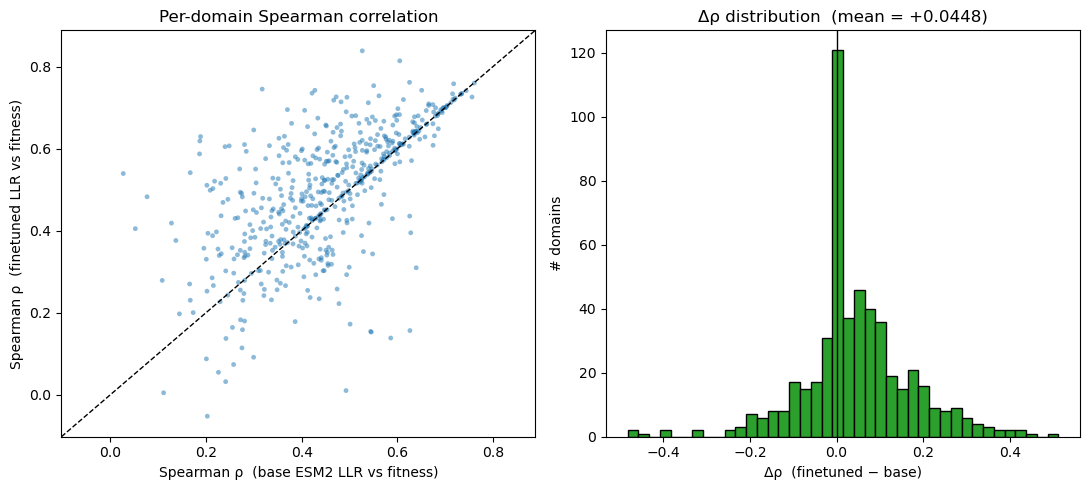

In [ ]:
# ── Plot: per-domain Spearman, base vs finetuned ─────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

lo = float(min(corr_df["rho_base"].min(), corr_df["rho_ft"].min())) - 0.05
hi = float(max(corr_df["rho_base"].max(), corr_df["rho_ft"].max())) + 0.05

axes[0].scatter(corr_df["rho_base"], corr_df["rho_ft"],
                alpha=0.5, s=12, edgecolor="none")
axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0].set_xlim(lo, hi); axes[0].set_ylim(lo, hi)
axes[0].set_xlabel("Spearman ρ  (base ESM2 LLR vs fitness)")
axes[0].set_ylabel("Spearman ρ  (finetuned LLR vs fitness)")
axes[0].set_title("Per-domain Spearman correlation")

axes[1].hist(corr_df["delta_rho"], bins=40, color="C2", edgecolor="black")
axes[1].axvline(0, color="k", linewidth=1)
axes[1].set_xlabel("Δρ  (finetuned − base)")
axes[1].set_ylabel("# domains")
axes[1].set_title(f"Δρ distribution  (mean = {corr_df['delta_rho'].mean():+.4f})")

plt.tight_layout()
plt.show()